# Feature Extraction + SVM Experiments

This notebook compares feature extraction strategies on `cropped_dataset` using the same classifier pipeline for every experiment:

- resize every image to `64x64` before feature extraction
- Raw Pixels baseline: grayscale pixels
- Color Histogram: HSV histogram
- HOG variants: grayscale, CLAHE, Hue channel, YUV channels
- HOG + Color Histogram: each HOG variant concatenated with HSV color histogram
- classifier: `StandardScaler -> SVM`

The validation split is used to choose the best feature combination. The test split is used only once for the final evaluation.

## Dependencies

If the import cell below fails, install the missing packages in the current notebook kernel:

```python
%pip install scikit-learn scikit-image opencv-python pandas numpy matplotlib
```


In [2]:
from pathlib import Path
from time import perf_counter
import warnings

import cv2
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage.feature import hog
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
try:
    from tqdm.auto import tqdm
except ModuleNotFoundError:
    def tqdm(iterable=None, **kwargs):
        return iterable if iterable is not None else []

warnings.filterwarnings('ignore', category=UserWarning)
plt.style.use('ggplot')

RANDOM_STATE = 42
DATASET_DIR = Path('cropped_dataset')
RESULTS_DIR = Path('log')
TARGET_SIZE = (64, 64)  # cv2 uses (width, height)
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

HOG_PARAMS = {
    'orientations': 9,
    'pixels_per_cell': (8, 8),
    'cells_per_block': (2, 2),
    'block_norm': 'L2-Hys',
    'transform_sqrt': True,
    'feature_vector': True,
}

COLOR_HIST_BINS = (8, 8, 8)

SVM_PARAMS = {
    'kernel': 'rbf',
    'C': 10.0,
    'gamma': 'scale',
    'class_weight': 'balanced',
    'cache_size': 1024,
}

np.random.seed(RANDOM_STATE)
RESULTS_DIR.mkdir(exist_ok=True)

print('Config ready')

Config ready


/home/dacekey/AIL303_SUM26/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def read_image_bgr(path: Path):
    """Read image paths robustly, including class folders with non-ASCII names."""
    data = np.fromfile(str(path), dtype=np.uint8)
    image = cv2.imdecode(data, cv2.IMREAD_COLOR)
    return image


def resize_bgr(image_bgr: np.ndarray) -> np.ndarray:
    height, width = image_bgr.shape[:2]
    interpolation = cv2.INTER_AREA if height > TARGET_SIZE[1] or width > TARGET_SIZE[0] else cv2.INTER_CUBIC
    return cv2.resize(image_bgr, TARGET_SIZE, interpolation=interpolation)


def get_class_names(dataset_dir: Path) -> list[str]:
    train_dir = dataset_dir / 'train'
    if not train_dir.exists():
        raise FileNotFoundError(f'Missing training directory: {train_dir}')
    return sorted(path.name for path in train_dir.iterdir() if path.is_dir())


def collect_split_paths(dataset_dir: Path, split: str, class_names: list[str]) -> tuple[list[Path], np.ndarray]:
    paths = []
    labels = []
    split_dir = dataset_dir / split
    for label, class_name in enumerate(class_names):
        class_dir = split_dir / class_name
        if not class_dir.exists():
            print(f'Warning: missing class folder in {split}: {class_name}')
            continue
        class_paths = [p for p in sorted(class_dir.iterdir()) if p.suffix.lower() in IMAGE_EXTENSIONS]
        paths.extend(class_paths)
        labels.extend([label] * len(class_paths))
    return paths, np.asarray(labels, dtype=np.int64)


def load_split(dataset_dir: Path, split: str, class_names: list[str]) -> tuple[np.ndarray, np.ndarray, list[Path]]:
    paths, labels = collect_split_paths(dataset_dir, split, class_names)
    images = []
    bad_paths = []
    kept_labels = []
    kept_paths = []

    for path, label in tqdm(list(zip(paths, labels)), desc=f'Loading {split}'):
        image = read_image_bgr(path)
        if image is None:
            bad_paths.append(path)
            continue
        images.append(resize_bgr(image))
        kept_labels.append(label)
        kept_paths.append(path)

    if bad_paths:
        print(f'Skipped {len(bad_paths)} unreadable images from {split}')
    if not images:
        raise ValueError(f'No images loaded for split: {split}')

    return np.stack(images).astype(np.uint8), np.asarray(kept_labels, dtype=np.int64), kept_paths


def summarize_labels(y: np.ndarray, class_names: list[str], split: str) -> pd.DataFrame:
    counts = pd.Series(y).value_counts().sort_index()
    return pd.DataFrame({
        'split': split,
        'class_id': counts.index,
        'class_name': [class_names[i] for i in counts.index],
        'count': counts.values,
    })

In [4]:
class_names = get_class_names(DATASET_DIR)
label_to_name = dict(enumerate(class_names))

data = {}
for split in ['train', 'val', 'test']:
    images, labels, paths = load_split(DATASET_DIR, split, class_names)
    data[split] = {'images': images, 'y': labels, 'paths': paths}
    print(f'{split}: {images.shape[0]} images, image tensor shape={images.shape}')

label_summary = pd.concat(
    [summarize_labels(data[split]['y'], class_names, split) for split in ['train', 'val', 'test']],
    ignore_index=True,
)

display(label_summary.groupby('split')['count'].agg(['sum', 'min', 'median', 'max']))
display(label_summary.head())

Loading train: 100%|███████████████| 6605/6605 [00:03<00:00, 1723.11it/s]


train: 6605 images, image tensor shape=(6605, 64, 64, 3)


Loading val: 100%|███████████████████| 824/824 [00:00<00:00, 1665.94it/s]


val: 824 images, image tensor shape=(824, 64, 64, 3)


Loading test: 100%|██████████████████| 851/851 [00:00<00:00, 1930.30it/s]

test: 851 images, image tensor shape=(851, 64, 64, 3)


,sum,min,median,max
split,,,,
test,851,3,11.0,108
train,6605,16,84.0,856
val,824,2,10.0,107


,split,class_id,class_name,count
0,train,0,B.8a,65
1,train,1,Camera,30
2,train,2,I.407a,156
3,train,3,I.409,20
4,train,4,I.434a,170


In [5]:
def as_gray_float(image_bgr: np.ndarray) -> np.ndarray:
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    return gray.astype(np.float32) / 255.0


def as_clahe_float(image_bgr: np.ndarray) -> np.ndarray:
    gray_uint8 = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray_uint8)
    return enhanced.astype(np.float32) / 255.0


def as_hue_float(image_bgr: np.ndarray) -> np.ndarray:
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    return hsv[:, :, 0].astype(np.float32) / 179.0


def as_yuv_float_channels(image_bgr: np.ndarray) -> list[np.ndarray]:
    yuv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2YUV)
    return [yuv[:, :, channel].astype(np.float32) / 255.0 for channel in range(3)]


def extract_raw_gray(images_bgr: np.ndarray) -> np.ndarray:
    features = [as_gray_float(image).ravel() for image in tqdm(images_bgr, desc='Raw gray')]
    return np.vstack(features).astype(np.float32)


def extract_hsv_histogram(images_bgr: np.ndarray, bins: tuple[int, int, int] = COLOR_HIST_BINS) -> np.ndarray:
    features = []
    hist_ranges = [0, 180, 0, 256, 0, 256]
    for image in tqdm(images_bgr, desc='HSV hist'):
        hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
        hist = cv2.calcHist([hsv], [0, 1, 2], None, bins, hist_ranges).astype(np.float32)
        hist = hist.ravel()
        hist /= hist.sum() + 1e-8
        features.append(hist)
    return np.vstack(features).astype(np.float32)


def hog_channel(channel_float: np.ndarray) -> np.ndarray:
    return hog(channel_float, **HOG_PARAMS).astype(np.float32)


def extract_hog(images_bgr: np.ndarray, variant: str) -> np.ndarray:
    features = []
    for image in tqdm(images_bgr, desc=f'HOG {variant}'):
        if variant == 'gray':
            vec = hog_channel(as_gray_float(image))
        elif variant == 'clahe':
            vec = hog_channel(as_clahe_float(image))
        elif variant == 'hue':
            vec = hog_channel(as_hue_float(image))
        elif variant == 'yuv':
            vec = np.concatenate([hog_channel(channel) for channel in as_yuv_float_channels(image)])
        else:
            raise ValueError(f'Unknown HOG variant: {variant}')
        features.append(vec)
    return np.vstack(features).astype(np.float32)

In [6]:
FEATURE_CACHE = {}

FEATURE_LABELS = {
    'raw_gray': 'Raw Pixels (gray)',
    'hist_hsv': 'Color Histogram (HSV)',
    'hog_gray': 'HOG (gray)',
    'hog_clahe': 'HOG (CLAHE)',
    'hog_hue': 'HOG (Hue)',
    'hog_yuv': 'HOG (YUV)',
}


def get_feature_matrix(split: str, feature_key: str) -> np.ndarray:
    cache_key = (split, feature_key)
    if cache_key in FEATURE_CACHE:
        return FEATURE_CACHE[cache_key]

    images = data[split]['images']
    if feature_key == 'raw_gray':
        matrix = extract_raw_gray(images)
    elif feature_key == 'hist_hsv':
        matrix = extract_hsv_histogram(images)
    elif feature_key.startswith('hog_'):
        matrix = extract_hog(images, feature_key.replace('hog_', ''))
    else:
        raise ValueError(f'Unknown feature key: {feature_key}')

    FEATURE_CACHE[cache_key] = matrix.astype(np.float32)
    print(f'{split}/{feature_key}: {FEATURE_CACHE[cache_key].shape}')
    return FEATURE_CACHE[cache_key]


def compose_features(split: str, feature_keys: tuple[str, ...]) -> np.ndarray:
    matrices = [get_feature_matrix(split, key) for key in feature_keys]
    if len(matrices) == 1:
        return matrices[0]
    return np.hstack(matrices).astype(np.float32)


def feature_name(feature_keys: tuple[str, ...]) -> str:
    return ' + '.join(FEATURE_LABELS[key] for key in feature_keys)

In [7]:
hog_variants = ['gray', 'clahe', 'hue', 'yuv']

experiments = [
    {'case': 'Raw Pixels (Baseline)', 'feature_keys': ('raw_gray',)},
    {'case': 'Color Histogram', 'feature_keys': ('hist_hsv',)},
]

for variant in hog_variants:
    experiments.append({
        'case': f'HOG only - {variant}',
        'feature_keys': (f'hog_{variant}',),
    })

for variant in hog_variants:
    experiments.append({
        'case': f'HOG + Color Histogram - {variant}',
        'feature_keys': (f'hog_{variant}', 'hist_hsv'),
    })

pd.DataFrame({
    'case': [experiment['case'] for experiment in experiments],
    'features': [feature_name(experiment['feature_keys']) for experiment in experiments],
})

,case,features
0,Raw Pixels (Baseline),Raw Pixels (gray)
1,Color Histogram,Color Histogram (HSV)
2,HOG only - gray,HOG (gray)
3,HOG only - clahe,HOG (CLAHE)
4,HOG only - hue,HOG (Hue)
5,HOG only - yuv,HOG (YUV)
6,HOG + Color Histogram - gray,HOG (gray) + Color Histogram (HSV)
7,HOG + Color Histogram - clahe,HOG (CLAHE) + Color Histogram (HSV)
8,HOG + Color Histogram - hue,HOG (Hue) + Color Histogram (HSV)
9,HOG + Color Histogram - yuv,HOG (YUV) + Color Histogram (HSV)


In [8]:
def build_svm_pipeline():
    return make_pipeline(
        StandardScaler(),
        SVC(**SVM_PARAMS),
    )


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'macro_precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }


def train_and_validate(experiment: dict) -> tuple[dict, object]:
    feature_keys = experiment['feature_keys']
    X_train = compose_features('train', feature_keys)
    X_val = compose_features('val', feature_keys)
    y_train = data['train']['y']
    y_val = data['val']['y']

    model = build_svm_pipeline()
    started = perf_counter()
    model.fit(X_train, y_train)
    train_seconds = perf_counter() - started

    val_pred = model.predict(X_val)
    metrics = compute_metrics(y_val, val_pred)
    result = {
        'case': experiment['case'],
        'features': feature_name(feature_keys),
        'feature_keys': '+'.join(feature_keys),
        'n_features': X_train.shape[1],
        'train_seconds': train_seconds,
        **{f'val_{key}': value for key, value in metrics.items()},
    }
    return result, model

In [9]:
validation_results = []
trained_models = {}

for experiment in experiments:
    print(f"\nRunning: {experiment['case']}")
    result, model = train_and_validate(experiment)
    validation_results.append(result)
    trained_models[result['case']] = model
    print(
        f"val_macro_f1={result['val_macro_f1']:.4f}, "
        f"val_accuracy={result['val_accuracy']:.4f}, "
        f"n_features={result['n_features']}, "
        f"train_seconds={result['train_seconds']:.1f}"
    )

results_df = pd.DataFrame(validation_results).sort_values('val_macro_f1', ascending=False).reset_index(drop=True)
display(results_df)

results_path = RESULTS_DIR / 'feature_svm_validation_results.csv'
results_df.to_csv(results_path, index=False)
print(f'Saved validation results to {results_path}')


Running: Raw Pixels (Baseline)


Raw gray: 100%|███████████████████| 6605/6605 [00:00<00:00, 81131.18it/s]


train/raw_gray: (6605, 4096)


Raw gray: 100%|█████████████████████| 824/824 [00:00<00:00, 95760.90it/s]


val/raw_gray: (824, 4096)
val_macro_f1=0.9340, val_accuracy=0.9430, n_features=4096, train_seconds=59.9

Running: Color Histogram


...

train/hog_yuv: (6605, 5292)


HOG yuv: 100%|████████████████████████| 824/824 [00:02<00:00, 322.36it/s]


val/hog_yuv: (824, 5292)
val_macro_f1=0.9274, val_accuracy=0.9551, n_features=5292, train_seconds=135.8

Running: HOG + Color Histogram - gray
val_macro_f1=0.9327, val_accuracy=0.9551, n_features=2276, train_seconds=40.2

Running: HOG + Color Histogram - clahe
val_macro_f1=0.9137, val_accuracy=0.9430, n_features=2276, train_seconds=41.6

Running: HOG + Color Histogram - hue
val_macro_f1=0.7986, val_accuracy=0.8799, n_features=2276, train_seconds=68.4

Running: HOG + Color Histogram - yuv
val_macro_f1=0.9209, val_accuracy=0.9551, n_features=5804, train_seconds=142.9


,case,features,feature_keys,n_features,train_seconds,val_accuracy,val_balanced_accuracy,val_macro_precision,val_macro_recall,val_macro_f1,val_weighted_f1
0,Raw Pixels (Baseline),Raw Pixels (gray),raw_gray,4096,59.909299,0.942961,0.914509,0.972344,0.914509,0.934047,0.942376
1,HOG + Color Histogram - gray,HOG (gray) + Color Histogram (HSV),hog_gray+hist_hsv,2276,40.240549,0.955097,0.914015,0.963898,0.914015,0.932733,0.953546
2,HOG only - gray,HOG (gray),hog_gray,1764,29.588671,0.952670,0.911813,0.958103,0.911813,0.928592,0.950699
3,HOG only - yuv,HOG (YUV),hog_yuv,5292,135.790715,0.955097,0.911709,0.958130,0.911709,0.927394,0.952822
4,HOG + Color Histogram - yuv,HOG (YUV) + Color Histogram (HSV),hog_yuv+hist_hsv,5804,142.904578,0.955097,0.901814,0.959402,0.901814,0.920911,0.952630
5,HOG only - clahe,HOG (CLAHE),hog_clahe,1764,29.747546,0.941748,0.903170,0.953634,0.903170,0.920812,0.939684
6,HOG + Color Histogram - clahe,HOG (CLAHE) + Color Histogram (HSV),hog_clahe+hist_hsv,2276,41.565585,0.942961,0.890599,0.956877,0.890599,0.913737,0.940918
7,Color Histogram,Color Histogram (HSV),hist_hsv,512,3.177264,0.907767,0.891688,0.942202,0.891688,0.906096,0.908443
8,HOG + Color Histogram - hue,HOG (Hue) + Color Histogram (HSV),hog_hue+hist_hsv,2276,68.407465,0.879854,0.769180,0.866485,0.769180,0.798609,0.872120
9,HOG only - hue,HOG (Hue),hog_hue,1764,48.210326,0.765777,0.592602,0.706008,0.592602,0.625645,0.753311


Saved validation results to log/feature_svm_validation_results.csv


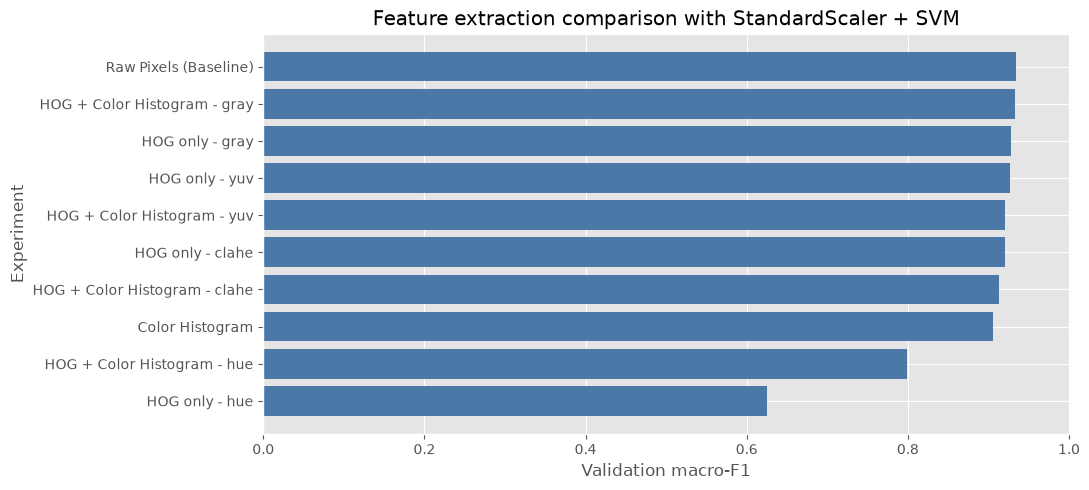

In [10]:
plt.figure(figsize=(11, 5))
plot_df = results_df.sort_values('val_macro_f1', ascending=True)
plt.barh(plot_df['case'], plot_df['val_macro_f1'], color='#4c78a8')
plt.xlabel('Validation macro-F1')
plt.ylabel('Experiment')
plt.title('Feature extraction comparison with StandardScaler + SVM')
plt.xlim(0, max(1.0, plot_df['val_macro_f1'].max() * 1.05))
plt.tight_layout()
plt.show()


In [11]:
best_row = results_df.iloc[0]
best_case = best_row['case']
best_feature_keys = tuple(best_row['feature_keys'].split('+'))
best_model = trained_models[best_case]

print('Best validation experiment')
display(best_row.to_frame(name='value'))

X_test = compose_features('test', best_feature_keys)
y_test = data['test']['y']
test_pred = best_model.predict(X_test)
test_metrics = compute_metrics(y_test, test_pred)

test_metrics_df = pd.DataFrame([{
    'case': best_case,
    'features': best_row['features'],
    **{f'test_{key}': value for key, value in test_metrics.items()},
}])

display(test_metrics_df)
print(classification_report(
    y_test,
    test_pred,
    labels=np.arange(len(class_names)),
    target_names=class_names,
    zero_division=0,
))

test_metrics_path = RESULTS_DIR / 'feature_svm_best_test_metrics.csv'
test_metrics_df.to_csv(test_metrics_path, index=False)
print(f'Saved test metrics to {test_metrics_path}')

Best validation experiment


,value
case,Raw Pixels (Baseline)
features,Raw Pixels (gray)
feature_keys,raw_gray
n_features,4096
train_seconds,59.909299
val_accuracy,0.942961
val_balanced_accuracy,0.914509
val_macro_precision,0.972344
val_macro_recall,0.914509
val_macro_f1,0.934047


Raw gray: 100%|█████████████████████| 851/851 [00:00<00:00, 80665.16it/s]

test/raw_gray: (851, 4096)


,case,features,test_accuracy,test_balanced_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_f1
0,Raw Pixels (Baseline),Raw Pixels (gray),0.93067,0.888986,0.956732,0.888986,0.912127,0.928818


                       precision    recall  f1-score   support

                 B.8a       1.00      1.00      1.00         9
               Camera       1.00      0.75      0.86         4
               I.407a       1.00      1.00      1.00        20
                I.409       1.00      0.67      0.80         3
               I.434a       1.00      1.00      1.00        22
                P.102       1.00      0.98      0.99        47
               P.103a       1.00      0.50      0.67         6
                P.104       1.00      1.00      1.00         5
        P.106a_Xe tải       1.00      0.89      0.94         9
                P.107       0.96      1.00      0.98        22
                P.111       1.00      1.00      1.00        47
               P.117_       1.00      1.00      1.00         8
               P.123a       0.92      0.96      0.94        25
               P.123b       1.00      1.00      1.00        19
              P.124a_       0.90      0.82      0.86  

In [12]:
def top_confusions(y_true: np.ndarray, y_pred: np.ndarray, class_names: list[str], top_n: int = 20) -> pd.DataFrame:
    columns = ['true_class', 'predicted_class', 'count']
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
    rows = []
    for true_id in range(cm.shape[0]):
        for pred_id in range(cm.shape[1]):
            if true_id == pred_id or cm[true_id, pred_id] == 0:
                continue

            rows.append({
                'true_class': class_names[true_id],
                'predicted_class': class_names[pred_id],
                'count': int(cm[true_id, pred_id]),
            })
    if not rows:
        return pd.DataFrame(columns=columns)
    return pd.DataFrame(rows, columns=columns).sort_values('count', ascending=False).head(top_n)


confusions_df = top_confusions(y_test, test_pred, class_names)
display(confusions_df)

confusions_path = RESULTS_DIR / 'feature_svm_best_test_confusions.csv'
confusions_df.to_csv(confusions_path, index=False)
print(f'Saved top confusions to {confusions_path}')

,true_class,predicted_class,count
16,P.130,P.131a,8
35,W.224,P.130,5
17,P.131a,P.130,4
14,P.127_80,P.127_60,3
33,W.207,W.224,2
4,P.103a,P.127_80,1
2,P.102,W.245a,1
3,P.103a,P.127_40,1
0,Camera,P.130,1
1,I.409,P.127_40,1


Saved top confusions to log/feature_svm_best_test_confusions.csv


In [13]:
model_path = RESULTS_DIR / 'best_feature_svm_pipeline.joblib'
metadata_path = RESULTS_DIR / 'best_feature_svm_metadata.joblib'

joblib.dump(best_model, model_path)
joblib.dump(
    {
        'best_case': best_case,
        'best_feature_keys': best_feature_keys,
        'class_names': class_names,
        'target_size': TARGET_SIZE,
        'hog_params': HOG_PARAMS,
        'color_hist_bins': COLOR_HIST_BINS,
        'svm_params': SVM_PARAMS,
    },
    metadata_path,
)

print(f'Saved best model to {model_path}')
print(f'Saved metadata to {metadata_path}')

Saved best model to log/best_feature_svm_pipeline.joblib
Saved metadata to log/best_feature_svm_metadata.joblib
